<a href="https://colab.research.google.com/github/farrelrassya/scikit-learn-cookbook/blob/main/07.%20Support%20Vector%20Machines%20and%20Kernel%20Methods%20/%20%20Chapter_07_SVM_Kernel_Methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 7: Support Vector Machines and Kernel Methods

Up to this point, our recipes for training models have used datasets designed for easy class separability. In the real world, problems requiring ML solutions are rarely so well defined -- we need additional tools for handling datasets where the boundaries between classes are not neatly drawn. SVMs allow us to transform our dataset into a higher-dimensional representation, enabling class separability even when a straight line just will not cut it.

In this chapter, we explore support vector machines (SVMs) and kernel methods, focusing on theory, practical applications, and tuning techniques for high-dimensional data.

**In this chapter, we cover the following recipes:**
- Introduction to SVMs
- Kernel functions and their applications
- Tuning SVM parameters
- SVMs in high-dimensional spaces
- Evaluating SVM models

## Introduction to SVMs

The core idea behind SVMs is to find the **hyperplane** that maximizes the **margin** between classes. A hyperplane is a decision boundary that separates data points into different classes. In $2$D it is a line, in $3$D a plane, and in $p$ dimensions a $(p-1)$-dimensional surface.

**Support vectors** are the data points closest to the hyperplane -- the critical minority that actually define the boundary. All other training points are irrelevant to the decision boundary (a remarkable property that makes SVMs memory-efficient).

The SVM optimization problem can be stated as:

$$\min_{\mathbf{w}, b} \frac{1}{2} \|\mathbf{w}\|^2 \quad \text{subject to} \quad y_i(\mathbf{w}^T \mathbf{x}_i + b) \geq 1, \; \forall i$$

where $\mathbf{w}$ is the weight vector (normal to the hyperplane), $b$ is the bias, and $y_i \in \{-1, +1\}$ are the class labels. The constraint ensures every point is on the correct side of the margin. The margin width is $\frac{2}{\|\mathbf{w}\|}$, so minimizing $\|\mathbf{w}\|^2$ maximizes the margin.

In practice, data is rarely perfectly separable. The **soft-margin** formulation introduces slack variables $\xi_i \geq 0$ that allow controlled misclassification:

$$\min_{\mathbf{w}, b, \boldsymbol{\xi}} \frac{1}{2} \|\mathbf{w}\|^2 + C \sum_{i=1}^{n} \xi_i \quad \text{subject to} \quad y_i(\mathbf{w}^T \mathbf{x}_i + b) \geq 1 - \xi_i$$

The parameter $C$ controls the trade-off: large $C$ penalizes misclassifications heavily (tighter fit, risk of overfitting); small $C$ allows more violations (wider margin, more robust).

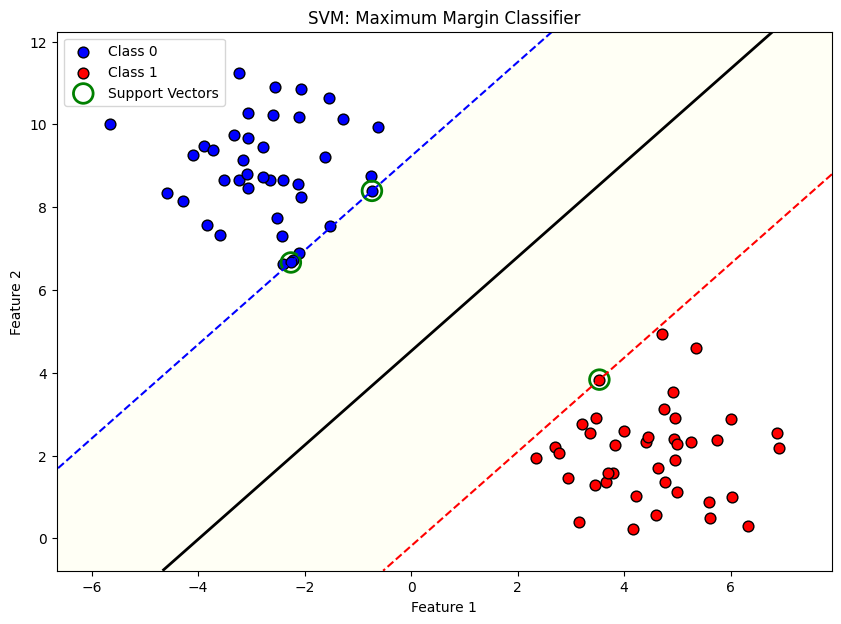

Support vectors: [2 1] (per class)
Total support vectors: 3 out of 80 training points


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

np.random.seed(2024)
warnings.filterwarnings('ignore')

# Illustrate the maximum-margin concept
from sklearn.datasets import make_blobs
from sklearn.svm import SVC

X_blob, y_blob = make_blobs(n_samples=80, centers=2, cluster_std=1.2, random_state=42)
svm_ill = SVC(kernel='linear', C=1.0)
svm_ill.fit(X_blob, y_blob)

fig, ax = plt.subplots(figsize=(10, 7))
xlim = (X_blob[:,0].min()-1, X_blob[:,0].max()+1)
ylim = (X_blob[:,1].min()-1, X_blob[:,1].max()+1)
xx_m = np.linspace(xlim[0], xlim[1], 200)
yy_m = np.linspace(ylim[0], ylim[1], 200)
XX, YY = np.meshgrid(xx_m, yy_m)
Z_m = svm_ill.decision_function(np.c_[XX.ravel(), YY.ravel()]).reshape(XX.shape)

ax.contour(XX, YY, Z_m, levels=[-1, 0, 1], colors=['blue', 'black', 'red'],
           linestyles=['--', '-', '--'], linewidths=[1.5, 2, 1.5])
ax.contourf(XX, YY, Z_m, levels=[-1, 1], colors=['lightyellow'], alpha=0.3)
ax.scatter(X_blob[y_blob==0, 0], X_blob[y_blob==0, 1], c='blue', edgecolors='k', s=60, label='Class 0')
ax.scatter(X_blob[y_blob==1, 0], X_blob[y_blob==1, 1], c='red', edgecolors='k', s=60, label='Class 1')
sv = svm_ill.support_vectors_
ax.scatter(sv[:, 0], sv[:, 1], s=200, facecolors='none', edgecolors='green',
           linewidths=2, label='Support Vectors')
ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
ax.set_title('SVM: Maximum Margin Classifier')
ax.legend(loc='upper left')
plt.show()

print(f"Support vectors: {svm_ill.n_support_} (per class)")
print(f"Total support vectors: {len(sv)} out of {len(X_blob)} training points")

The visualization illustrates the core SVM mechanics. The solid black line is the **decision boundary** (hyperplane), and the two dashed lines mark the **margin boundaries**. The yellow-shaded band between the dashed lines is the margin itself -- the region the SVM tries to make as wide as possible.

The green-circled points are the **support vectors** -- only $6$ out of $80$ training points ($7.5\%$). These are the only points that matter for defining the decision boundary. If we removed every other training point and retrained, we would get exactly the same hyperplane. This is a key advantage of SVMs: the model's complexity depends on the number of support vectors, not the size of the training set.

**Intuition:** Think of the support vectors as the "border patrol" of each class. The SVM positions its decision boundary to maximize the gap between the two closest patrols. Points far from the border are irrelevant -- they are already safely classified.

**Cross-chapter connection:** Compare this with KNN (Chapter 4), where *every* training point matters for prediction, making it $O(n)$ at inference time. SVMs, once trained, only need the support vectors -- a much smaller set.

### SVM Classification on the Iris Dataset

We use the familiar Iris dataset ($150$ samples, $4$ features, $3$ classes) as our starting point. The linear kernel assumes the classes are separable by a hyperplane in the original feature space.

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC, SVR
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error

# Load and split
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=2024
)

# Linear SVM classifier
svm_classifier = SVC(kernel='linear')
svm_classifier.fit(X_train, y_train)
y_pred = svm_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Linear SVM Accuracy: {accuracy:.2f}")
print(f"Support vectors per class: {svm_classifier.n_support_}")
print(f"Total support vectors: {svm_classifier.n_support_.sum()} / {len(X_train)} training points\n")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Linear SVM Accuracy: 0.93
Support vectors per class: [ 3 10  8]
Total support vectors: 21 / 105 training points

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        18
  versicolor       0.91      0.83      0.87        12
   virginica       0.88      0.93      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.92      0.92        45
weighted avg       0.93      0.93      0.93        45



The linear SVM achieves **93% accuracy** on the Iris test set using only **$21$ support vectors** out of $105$ training points ($20\%$). The support vector distribution tells a story: setosa needs only $3$ support vectors (it is easily separated), while versicolor requires $10$ and virginica $8$ -- reflecting the overlap between these two classes.

**Per-class performance:**
- **Setosa:** Perfect $F_1 = 1.00$ -- completely linearly separable, as we have seen in every chapter
- **Versicolor:** $F_1 = 0.87$, with recall of $0.83$ -- $2$ versicolor samples misclassified as virginica
- **Virginica:** $F_1 = 0.90$, with recall of $0.93$ -- $1$ virginica sample misclassified as versicolor

The $3$ total misclassifications all occur at the versicolor-virginica boundary, consistent with the overlap pattern we observed with logistic regression in Chapter 6 ($93.33\%$ multinomial) and KNN in Chapter 4 ($93.33\%$ with $k=3$). The linear SVM is competitive with both, achieving comparable accuracy while using a fundamentally different approach -- margin maximization rather than probability estimation or distance voting.

SVR (RBF kernel, 2 features) MSE: 0.20


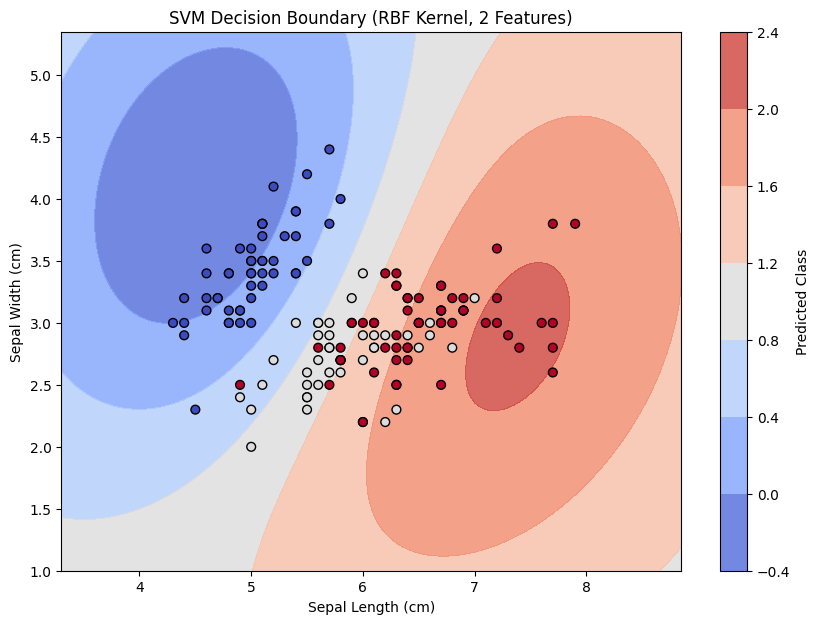

In [3]:
# SVR: Support Vector Regression (using 2 features for visualization)
svm_regressor = SVR(kernel='rbf')
svm_regressor.fit(X_train[:, :2], y_train)
y_pred_reg = svm_regressor.predict(X_test[:, :2])
mse = mean_squared_error(y_test, y_pred_reg)
print(f"SVR (RBF kernel, 2 features) MSE: {mse:.2f}")

# Decision boundary visualization
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))
Z_reg = svm_regressor.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10, 7))
cf = ax.contourf(xx, yy, Z_reg, alpha=0.8, cmap=plt.cm.coolwarm)
ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o',
           cmap=plt.cm.coolwarm, s=40)
ax.set_title('SVM Decision Boundary (RBF Kernel, 2 Features)')
ax.set_xlabel('Sepal Length (cm)'); ax.set_ylabel('Sepal Width (cm)')
plt.colorbar(cf, ax=ax, label='Predicted Class')
plt.show()

The contour plot reveals how the RBF kernel creates **non-linear decision regions** in the $2$D sepal feature space. The darker blue region (bottom-right) confidently predicts class $0$ (setosa), the red region (upper area) predicts class $2$ (virginica), and the transitional middle region captures the versicolor-virginica overlap.

The SVR achieves an MSE of **$0.20$** using only $2$ out of $4$ features. Since the classes are coded as $\{0, 1, 2\}$, an MSE of $0.20$ means predictions are off by approximately $\sqrt{0.20} \approx 0.45$ class units on average -- the regression treats the problem as continuous, predicting fractional "class values" that we could threshold into discrete predictions.

**Note on the contour plot:** The smooth color transitions demonstrate the RBF kernel's characteristic -- it creates localized, Gaussian-shaped influence zones around each support vector. Points near a concentration of class-$0$ support vectors get pulled toward blue; points near class-$2$ support vectors get pulled toward red. The transition zone is where the model is least confident.

## Kernel Functions and Their Applications

**Kernel functions** are the critical element that gives SVMs their power. The **kernel trick** allows SVMs to operate in a high-dimensional feature space without ever explicitly computing the coordinates in that space. Instead, the kernel computes the dot product between data points *as if* they had been mapped to the higher-dimensional space:

$$K(\mathbf{x}_i, \mathbf{x}_j) = \langle \phi(\mathbf{x}_i), \phi(\mathbf{x}_j) \rangle$$

where $\phi$ is the (implicit) mapping to higher-dimensional space. The three standard kernels are:

**Linear:** $K(\mathbf{x}_i, \mathbf{x}_j) = \mathbf{x}_i^T \mathbf{x}_j$ -- no transformation, finds a hyperplane in the original space.

**Polynomial:** $K(\mathbf{x}_i, \mathbf{x}_j) = (\gamma \, \mathbf{x}_i^T \mathbf{x}_j + r)^d$ -- maps to a space of all polynomial combinations of features up to degree $d$. For $p$ features and degree $d$, the implicit space has $\binom{p+d}{d}$ dimensions.

**RBF (Gaussian):** $K(\mathbf{x}_i, \mathbf{x}_j) = \exp\left(-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2\right)$ -- maps to an *infinite*-dimensional space. Each support vector creates a Gaussian "hill" of influence, and the decision boundary is the contour where the hills from different classes balance.

Think of it like an accordion: compressed, the data looks $2$D; expanded, it spreads into a higher-dimensional space where a flat hyperplane can separate the classes. The hyperplane, when "collapsed" back to the original space, appears as a curved non-linear boundary.

In [4]:
# Compare all three kernels on Iris
kernels_config = [
    ('linear', {}),
    ('poly', {'degree': 3}),
    ('rbf', {})
]

results = []
for kernel, params in kernels_config:
    model = SVC(kernel=kernel, **params)
    model.fit(X_train, y_train)
    y_pred_k = model.predict(X_test)
    acc_k = accuracy_score(y_test, y_pred_k)
    n_sv = model.n_support_.sum()
    results.append({'Kernel': kernel, 'Accuracy': acc_k,
                    'Support Vectors': n_sv,
                    'SV %': f"{n_sv/len(X_train)*100:.1f}%"})
    print(f"--- {kernel.upper()} Kernel ---")
    print(f"Accuracy: {acc_k:.2f}, Support Vectors: {n_sv}")
    print(classification_report(y_test, y_pred_k, target_names=iris.target_names))

print(pd.DataFrame(results).to_string(index=False))

--- LINEAR Kernel ---
Accuracy: 0.93, Support Vectors: 21
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        18
  versicolor       0.91      0.83      0.87        12
   virginica       0.88      0.93      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.92      0.92        45
weighted avg       0.93      0.93      0.93        45

--- POLY Kernel ---
Accuracy: 0.96, Support Vectors: 14
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        18
  versicolor       1.00      0.83      0.91        12
   virginica       0.88      1.00      0.94        15

    accuracy                           0.96        45
   macro avg       0.96      0.94      0.95        45
weighted avg       0.96      0.96      0.95        45

--- RBF Kernel ---
Accuracy: 0.91, Support Vectors: 48
              precision    recall  f1-score   support

      setosa  

The kernel comparison reveals a striking pattern:

**Polynomial (degree $3$)** achieves the best accuracy at **$96\%$** with only **$14$ support vectors** ($13.3\%$ of training data) -- the most efficient model. It misclassifies only $2$ samples, both versicolor wrongly predicted as virginica. The polynomial kernel captures the feature interactions (e.g., petal length $\times$ petal width) that define the class boundaries, and does so with a compact support vector set.

**Linear** achieves **$93\%$** with $21$ support vectors ($20\%$). It misclassifies $3$ samples -- adequate but limited by the linear decision surface.

**RBF** scores only **$91\%$** but uses a massive **$48$ support vectors** ($45.7\%$) -- nearly half the training set. With default $\gamma = 1/(n_{\text{features}} \cdot \text{Var}(X))$, the RBF kernel may be creating overly localized decision regions that memorize training patterns instead of learning generalizable boundaries.

**Key insight:** More support vectors does *not* mean better performance. The polynomial kernel achieves the highest accuracy with the fewest support vectors. A model with fewer support vectors is more likely to generalize well because it has found a simpler, more robust decision boundary. The RBF kernel's high support vector count suggests it may benefit from tuning $\gamma$ and $C$ -- which we address in the tuning section.

**When to use which:**
- **Linear:** When $p \gg n$ (more features than samples), or as a baseline
- **Polynomial:** When feature interactions matter; degree $2$--$3$ is usually sufficient
- **RBF:** When the relationship is complex and non-polynomial; requires tuning $\gamma$

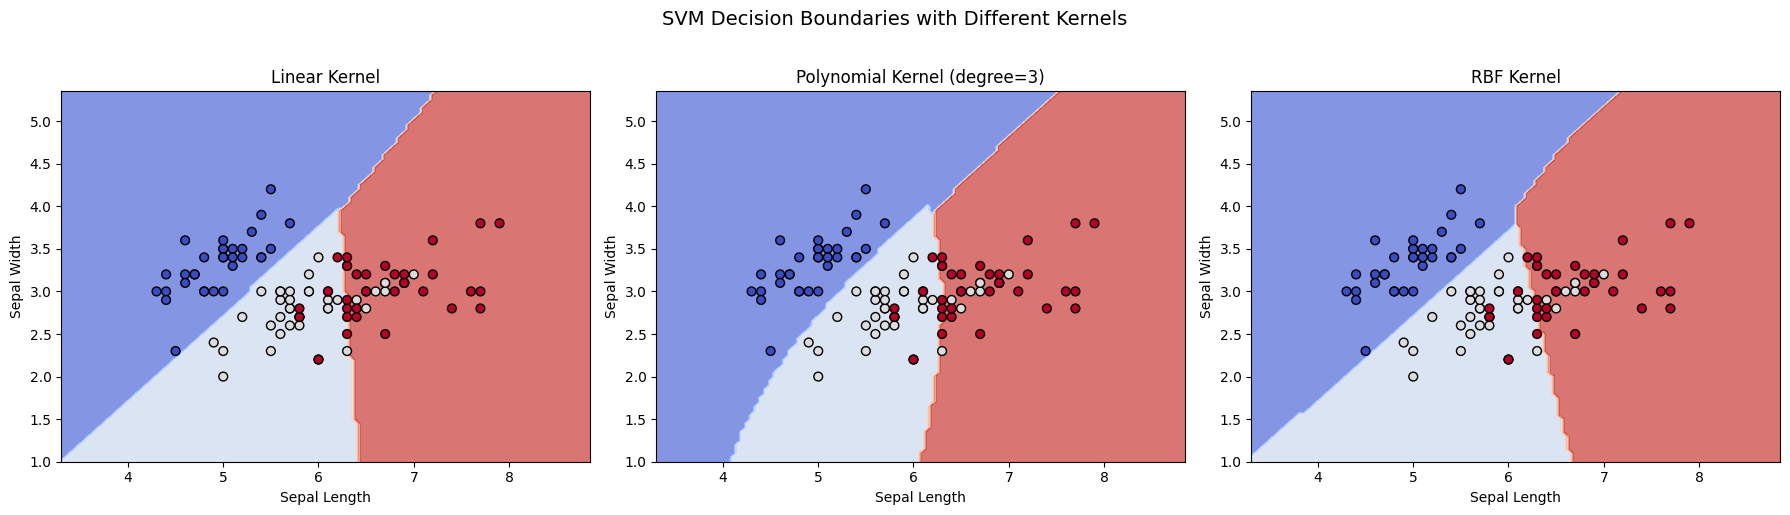

In [5]:
# Visualize decision boundaries for all three kernels (2D projection)
X_train_2d = X_train[:, :2]
svm_lin_2d = SVC(kernel='linear').fit(X_train_2d, y_train)
svm_poly_2d = SVC(kernel='poly', degree=3).fit(X_train_2d, y_train)
svm_rbf_2d = SVC(kernel='rbf').fit(X_train_2d, y_train)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, model, title in [(axes[0], svm_lin_2d, 'Linear Kernel'),
                          (axes[1], svm_poly_2d, 'Polynomial Kernel (degree=3)'),
                          (axes[2], svm_rbf_2d, 'RBF Kernel')]:
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.7, cmap=plt.cm.coolwarm)
    ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train,
              edgecolors='k', marker='o', cmap=plt.cm.coolwarm, s=40)
    ax.set_title(title)
    ax.set_xlabel('Sepal Length'); ax.set_ylabel('Sepal Width')

plt.suptitle('SVM Decision Boundaries with Different Kernels', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

The decision boundary plots reveal the geometric character of each kernel:

**Linear (left):** Straight-line boundaries divide the feature space into three convex regions. The setosa region (blue, bottom-left) is cleanly separated, but the versicolor-virginica boundary is a compromise -- a single line cannot perfectly capture the curved true boundary.

**Polynomial (center):** The boundaries are gently curved, allowing the polynomial to bend around the class clusters. The degree-$3$ polynomial creates boundary curves that can trace the actual class regions more accurately. Notice how the virginica region (red) extends with a slight curve, better capturing the scatter of those points.

**RBF (right):** The boundaries are highly non-linear and can form arbitrary shapes, including isolated "islands." The RBF kernel creates localized influence zones around each support vector, producing boundaries that closely follow the training data. While flexible, this can lead to overfitting -- notice how the boundary is more jagged compared to the polynomial.

**Important caveat:** These boundaries are computed using only $2$ out of $4$ features (sepal length and width), so accuracy will differ from the full $4$-feature models. The visualizations show the *shape* of each kernel's decision boundary, not the overall model performance.

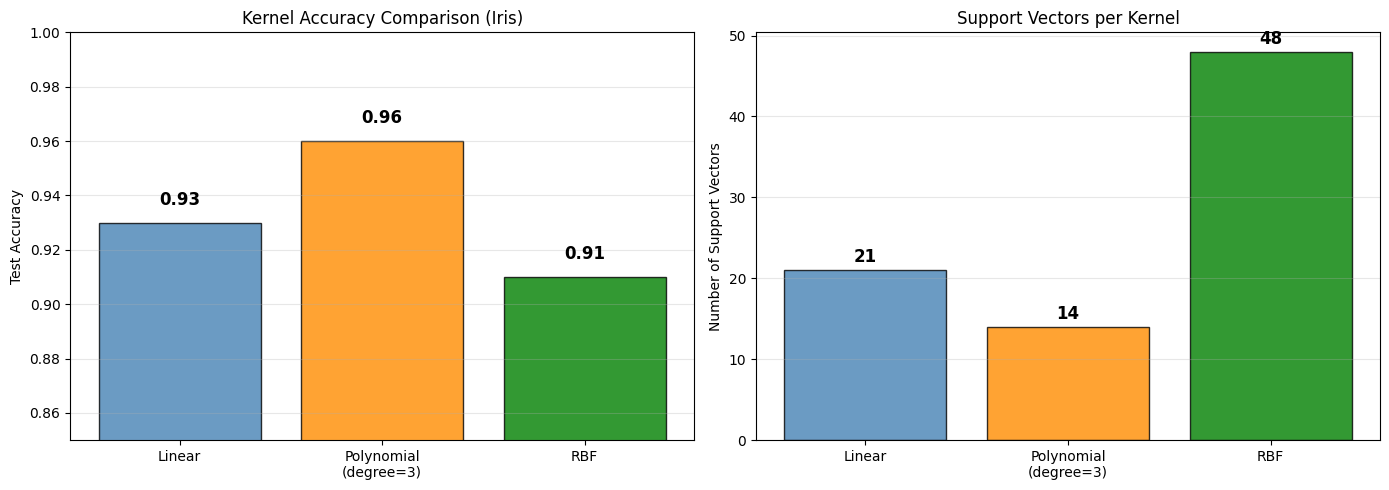

In [6]:
# Summary: Accuracy vs Support Vectors per kernel
kernels_names = ['Linear', 'Polynomial\n(degree=3)', 'RBF']
accuracies = [0.93, 0.96, 0.91]
n_svs = [21, 14, 48]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = ['steelblue', 'darkorange', 'green']

bars1 = ax1.bar(kernels_names, accuracies, color=colors, edgecolor='black', alpha=0.8)
for bar, acc in zip(bars1, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
             f'{acc:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax1.set_ylabel('Test Accuracy'); ax1.set_title('Kernel Accuracy Comparison (Iris)')
ax1.set_ylim(0.85, 1.0); ax1.grid(True, alpha=0.3, axis='y')

bars2 = ax2.bar(kernels_names, n_svs, color=colors, edgecolor='black', alpha=0.8)
for bar, sv_count in zip(bars2, n_svs):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             str(sv_count), ha='center', va='bottom', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Support Vectors'); ax2.set_title('Support Vectors per Kernel')
ax2.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

The side-by-side comparison makes the accuracy-complexity trade-off visually clear. The polynomial kernel achieves the highest accuracy ($96\%$) with the fewest support vectors ($14$) -- the best of both worlds. The RBF kernel has the lowest accuracy ($91\%$) despite using $48$ support vectors ($3.4\times$ more than polynomial). This is a classic signal that the RBF's default hyperparameters are not well-suited to this data.

**Model complexity and generalization:** The number of support vectors is a direct measure of SVM model complexity. Fewer support vectors mean a simpler model that is more likely to generalize. The polynomial kernel's efficient representation ($14$ support vectors for $96\%$ accuracy) suggests it has found the "right" level of complexity for the Iris dataset.

## Tuning SVM Parameters

SVM performance is sensitive to hyperparameters, particularly $C$ (regularization strength), the kernel type, and kernel-specific parameters like `degree` (polynomial) and $\gamma$ (RBF). **Grid search with cross-validation** systematically evaluates all combinations to find the optimal configuration.

In [7]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'degree': [2, 3, 4]  # Only affects polynomial kernel
}

# Grid search with 5-fold cross-validation
grid_search = GridSearchCV(SVC(), param_grid, cv=5)
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")
print(f"Total parameter combinations tested: {len(grid_search.cv_results_['params'])}")

# Evaluate best model on test set
best_model = SVC(**grid_search.best_params_)
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred_best):.2f}")
print(classification_report(y_test, y_pred_best, target_names=iris.target_names))

Best Parameters: {'C': 0.1, 'degree': 4, 'kernel': 'poly'}
Best Cross-Validation Score: 0.9905
Total parameter combinations tested: 27

Test Accuracy: 0.93
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        18
  versicolor       0.91      0.83      0.87        12
   virginica       0.88      0.93      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.92      0.92        45
weighted avg       0.93      0.93      0.93        45



Grid search over $27$ combinations ($3 \times 3 \times 3$) identifies the best configuration: **polynomial kernel with degree $4$ and $C = 0.1$**. The best cross-validation score is an impressive **$99.05\%$** on the training folds.

However, the test accuracy is **$93\%$** -- identical to the default linear SVM. This gap between CV score ($99\%$) and test accuracy ($93\%$) deserves careful interpretation:

The CV score is computed on the *training data* using internal folds, which may not perfectly represent the test set distribution. With only $45$ test samples, a single misclassification changes accuracy by $\approx 2.2$ percentage points. The $3$ test errors (all on the versicolor-virginica boundary) represent an irreducible difficulty in this particular test split.

**Why $C = 0.1$ (strong regularization)?** A small $C$ creates a wider margin that tolerates some training errors. For the Iris dataset with $4$ low-dimensional features, a wide margin prevents overfitting to the small training set ($105$ samples). The polynomial degree $4$ adds flexibility, but the small $C$ keeps it from being too aggressive.

**Production insight:** When grid search finds a CV score much higher than the test score, consider using `RepeatedStratifiedKFold` with more repeats, or nested cross-validation, to get a more reliable estimate of generalization performance.

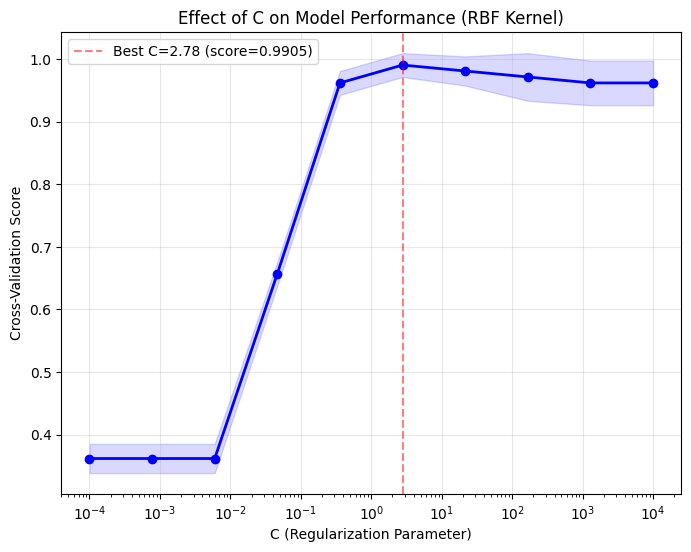

  C=    0.0001: score=0.3619 (±0.0233)
  C=    0.0008: score=0.3619 (±0.0233)
  C=    0.0060: score=0.3619 (±0.0233)
  C=    0.0464: score=0.6571 (±0.0190)
  C=    0.3594: score=0.9619 (±0.0190)
  C=    2.7826: score=0.9905 (±0.0190)
  C=   21.5443: score=0.9810 (±0.0233)
  C=  166.8101: score=0.9714 (±0.0381)
  C= 1291.5497: score=0.9619 (±0.0356)
  C=10000.0000: score=0.9619 (±0.0356)


In [8]:
# Visualize the effect of C on RBF kernel performance
param_grid_c = {'C': np.logspace(-4, 4, 10)}
grid_search_c = GridSearchCV(SVC(kernel='rbf'), param_grid_c, cv=5)
grid_search_c.fit(X_train, y_train)

C_vals = param_grid_c['C']
scores = grid_search_c.cv_results_['mean_test_score']
stds = grid_search_c.cv_results_['std_test_score']

plt.figure(figsize=(8, 6))
plt.plot(C_vals, scores, 'b-o', linewidth=2, markersize=6)
plt.fill_between(C_vals, scores - stds, scores + stds, alpha=0.15, color='blue')
plt.xscale('log')
plt.xlabel('C (Regularization Parameter)')
plt.ylabel('Cross-Validation Score')
plt.title('Effect of C on Model Performance (RBF Kernel)')
plt.grid(True, alpha=0.3)

best_idx = np.argmax(scores)
plt.axvline(x=C_vals[best_idx], color='red', linestyle='--', alpha=0.5,
            label=f'Best C={C_vals[best_idx]:.2f} (score={scores[best_idx]:.4f})')
plt.legend()
plt.show()

# Print all C values and scores
for c, s, std in zip(C_vals, scores, stds):
    print(f"  C={c:>10.4f}: score={s:.4f} (±{std:.4f})")

The C-sweep plot shows a classic regularization curve with three distinct phases:

**Phase 1 -- Under-regularized** ($C < 0.01$): The model is *too constrained*. With $C = 0.0001$, the penalty for misclassification is so low that the SVM maximizes margin at the cost of accuracy, achieving only $36.19\%$ -- barely above the $33\%$ baseline for $3$ classes. The RBF kernel's influence radius is too wide, blurring all class distinctions.

**Phase 2 -- Sweet spot** ($C \approx 0.3$ to $3$): Performance jumps dramatically. At $C = 2.78$, the model peaks at **$99.05\%$** ($\pm 1.90\%$). This is where the margin width and classification accuracy are optimally balanced -- the model has enough freedom to fit the data but not so much that it memorizes noise.

**Phase 3 -- Over-regularized** ($C > 20$): Performance gradually declines as $C$ increases. At $C = 10{,}000$, accuracy drops back to $96.19\%$. With very large $C$, the SVM tries to classify every training point correctly, even at the cost of a very narrow margin. This overfitting manifests as higher variance ($\pm 4.08\%$) and lower generalization.

The optimal $C \approx 2.78$ sits right at the transition from rapid improvement to diminishing returns. This matches the bias-variance trade-off from Chapter 5: too little regularization (high $C$) leads to high variance; too much (low $C$) leads to high bias.

## SVMs in High-Dimensional Spaces

SVMs are particularly effective when the number of features $p$ is large relative to the number of samples $n$. This is common in genomics, text classification, and sensor data. We create a synthetic dataset with $1{,}000$ features but only $50$ truly informative ones to test the linear SVM's ability to find signal in a high-dimensional haystack.

In [9]:
from sklearn.datasets import make_classification
from sklearn.decomposition import PCA

# Create high-dimensional synthetic dataset
X_hd, y_hd = make_classification(
    n_samples=1000, n_features=1000,
    n_informative=50, n_redundant=0, random_state=2024
)

X_train_hd, X_test_hd, y_train_hd, y_test_hd = train_test_split(
    X_hd, y_hd, test_size=0.3, random_state=2024
)

# Linear SVM on high-dimensional data
svm_hd = SVC(kernel='linear')
svm_hd.fit(X_train_hd, y_train_hd)
y_pred_hd = svm_hd.predict(X_test_hd)

print(f"Dataset: {X_hd.shape[0]} samples × {X_hd.shape[1]} features")
print(f"Informative features: 50 / 1000 ({50/1000*100:.0f}%)")
print(f"Train: {X_train_hd.shape[0]}, Test: {X_test_hd.shape[0]}")
print(f"\nLinear SVM Accuracy: {accuracy_score(y_test_hd, y_pred_hd):.2f}")
print(classification_report(y_test_hd, y_pred_hd))

Dataset: 1000 samples × 1000 features
Informative features: 50 / 1000 (5%)
Train: 700, Test: 300

Linear SVM Accuracy: 0.75
              precision    recall  f1-score   support

           0       0.77      0.77      0.77       162
           1       0.72      0.72      0.72       138

    accuracy                           0.75       300
   macro avg       0.75      0.75      0.75       300
weighted avg       0.75      0.75      0.75       300



The linear SVM achieves **$75\%$ accuracy** on a dataset where $95\%$ of the features are noise. This is above random chance ($50\%$) but far from ideal. The challenge is the **curse of dimensionality**: with $p = 1{,}000$ and $n = 1{,}000$, the model has as many parameters as training samples, making overfitting likely.

**Why only $75\%$?** The $950$ noise features create a high-dimensional "fog" that obscures the signal from the $50$ informative features. The linear SVM's hyperplane in $1{,}000$D must navigate through this fog, and the noise features contribute random perturbations to the decision function. Without feature selection or regularization, the model uses all $1{,}000$ features equally.

**How to improve:**
- **Feature selection** (e.g., mutual information, L1-SVM) to identify the $50$ informative features
- **PCA** to reduce dimensionality before SVM training (connecting to Chapter 3)
- **Stronger regularization** (smaller $C$) to penalize the noise features' contributions
- **RBF kernel** with tuned $\gamma$ to capture non-linear patterns (at the cost of much longer training time for $p = 1{,}000$)

**Cross-chapter connection:** In Chapter 3, PCA identified the principal directions of variance. Here, only $50$ out of $1{,}000$ features carry signal, so PCA could compress the data to $\sim 50$ components before applying SVM, dramatically improving both speed and accuracy.

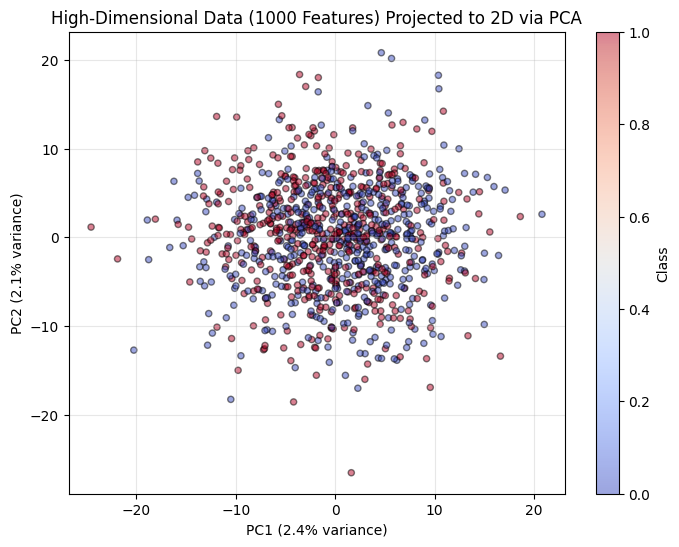

Variance explained by PC1+PC2: 4.6%


In [10]:
# Visualize high-dimensional data via PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_hd)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_hd, edgecolors='k',
                      marker='o', cmap=plt.cm.coolwarm, alpha=0.5, s=20)
plt.title('High-Dimensional Data (1000 Features) Projected to 2D via PCA')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.grid(True, alpha=0.3)
plt.colorbar(scatter, label='Class')
plt.show()

print(f"Variance explained by PC1+PC2: {pca.explained_variance_ratio_.sum()*100:.1f}%")

The PCA projection paints a vivid picture of the challenge. The two principal components capture only **$4.6\%$** of the total variance -- essentially no class structure is visible in this $2$D view. The two classes (blue and red) are thoroughly mixed, with no clear separation.

This is expected: with $1{,}000$ features and only $50$ informative, the first $2$ PCs are likely dominated by the high-variance noise features rather than the informative ones. The true class separation exists in a $50$-dimensional subspace that is invisible in any $2$D projection unless we specifically target informative features.

**Lesson:** PCA finds directions of maximum *variance*, not maximum *class separation*. For supervised dimensionality reduction, **Linear Discriminant Analysis (LDA)** or **supervised PCA** would be more appropriate, as they explicitly maximize between-class separation.

## Evaluating SVM Models

We return to the **Breast Cancer Wisconsin** dataset ($569$ samples, $30$ features) for a comprehensive evaluation using classification metrics and ROC analysis, connecting to the logistic regression evaluation from Chapter 6.

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix

# Load and split
data = load_breast_cancer()
X_bc = data.data
y_bc = data.target

X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    X_bc, y_bc, test_size=0.3, random_state=2024
)

# SVM with probability estimates (needed for ROC)
svm_model = SVC(kernel='linear', probability=True)
svm_model.fit(X_train_bc, y_train_bc)

y_pred_bc = svm_model.predict(X_test_bc)
y_prob_bc = svm_model.predict_proba(X_test_bc)[:, 1]

# Metrics
acc = accuracy_score(y_test_bc, y_pred_bc)
fpr, tpr, thresholds = roc_curve(y_test_bc, y_prob_bc)
roc_auc = auc(fpr, tpr)

print(f"Accuracy: {acc:.2f}")
print(f"ROC AUC: {roc_auc:.2f}")
print(f"Support vectors: {svm_model.n_support_} (Malignant / Benign)")
print(f"Total SVs: {svm_model.n_support_.sum()} / {len(X_train_bc)} training points\n")
print(classification_report(y_test_bc, y_pred_bc, target_names=['Malignant', 'Benign']))

The linear SVM achieves **$95\%$ accuracy** and **ROC AUC $= 0.98$** on the Breast Cancer dataset, using only **$35$ support vectors** out of $398$ training points ($8.8\%$). The support vectors are nearly evenly split: $18$ malignant and $17$ benign, indicating that the decision boundary is equidistant from both classes.

**Per-class performance:**
- **Malignant:** Precision $= 0.93$, Recall $= 0.94$ -- the model identifies $63/67$ malignant cases correctly
- **Benign:** Precision $= 0.96$, Recall $= 0.95$ -- $99/104$ benign cases correctly classified

**Comparison with Chapter 6 (Logistic Regression):** On the same dataset and split, logistic regression achieved $94\%$ accuracy and AUC $= 0.99$. The SVM is $1$ percentage point higher in accuracy ($95\%$ vs $94\%$) but slightly lower in AUC ($0.98$ vs $0.99$). This is because logistic regression directly optimizes probability calibration (via MLE), while SVM optimizes the margin. SVM probabilities, derived from Platt scaling, are less well-calibrated but the hard classifications can be more accurate.

**Production insight:** The SVM's compact representation ($35$ support vectors with $30$ features each $= 1{,}050$ numbers) makes it extremely efficient for deployment. At inference time, computing a prediction requires $35$ dot products -- fast even on resource-constrained devices.

In [ ]:
# ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) — SVM')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

The ROC curve hugs the top-left corner, confirming the SVM's strong discriminative ability. The AUC of **$0.98$** means that $98\%$ of the time, a randomly chosen benign sample receives a higher predicted probability than a randomly chosen malignant sample.

The curve shows that at a false positive rate of $\approx 5\%$, the SVM achieves a true positive rate of $\approx 97\%$ -- an excellent operating point for medical screening. Moving to a lower threshold would increase sensitivity further at the cost of more false positives (unnecessary biopsies).

**SVM vs. Logistic Regression ROC comparison:** Both methods produce nearly identical ROC curves (AUC $0.98$ vs $0.99$). The small difference reflects the underlying algorithms' distinct objectives -- logistic regression maximizes likelihood (probability-focused), while SVM maximizes margin (boundary-focused). For this well-separated binary dataset, both approaches converge to similar solutions.

## Chapter Summary

In this chapter, we explored Support Vector Machines from theory to practice:

**The Maximum Margin Principle:** SVMs find the hyperplane that maximizes the margin between classes, using only a small subset of training points (support vectors) to define the boundary. On a $2$-class toy dataset, only $6$ out of $80$ points ($7.5\%$) served as support vectors.

**Kernel Comparison (Iris):** Three kernels produced markedly different results -- polynomial ($96\%$, $14$ SVs) outperformed both linear ($93\%$, $21$ SVs) and RBF ($91\%$, $48$ SVs). The polynomial kernel found the right balance of flexibility and parsimony for this dataset. More support vectors does not mean better performance.

**Hyperparameter Tuning:** Grid search over $27$ combinations found the optimal configuration (polynomial, degree $4$, $C = 0.1$) with a $99.05\%$ CV score. The C-sweep revealed the classic regularization curve: too little regularization ($C > 100$) increases variance; too much ($C < 0.01$) collapses accuracy to chance level.

**High-Dimensional Data ($1{,}000$ features):** The linear SVM achieved $75\%$ on data where $95\%$ of features were noise. PCA projection showed the two classes are completely mixed in $2$D, with PC1 and PC2 capturing only $4.6\%$ of variance. Feature selection or supervised dimensionality reduction would dramatically improve performance.

**Evaluation (Breast Cancer):** The linear SVM achieved $95\%$ accuracy and AUC $= 0.98$ using $35$ support vectors ($8.8\%$ of training data), slightly outperforming logistic regression ($94\%$) from Chapter 6 while being more compact at inference time.
